In [26]:
bucket = "s3://csc555-data-dd9d74e8/raw/"

train = spark.read.csv(bucket + "train.csv", header=True, inferSchema=True)
members = spark.read.csv(bucket + "members_v3.csv", header=True, inferSchema=True)
transactions = spark.read.csv(bucket + "transactions.csv", header=True, inferSchema=True)
user_logs = spark.read.csv(bucket + "user_logs.csv", header=True, inferSchema=True)

print("train shape:", (train.count(), len(train.columns)))
print("members shape:", (members.count(), len(members.columns)))
print("transactions shape:", (transactions.count(), len(transactions.columns)))
print("user_logs shape:", (user_logs.count(), len(user_logs.columns)))

train.show(5)
members.show(5)
transactions.show(5)
user_logs.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

train shape: (992931, 2)
members shape: (6769473, 6)
transactions shape: (21547746, 9)
user_logs shape: (392106543, 9)
+--------------------+--------+
|                msno|is_churn|
+--------------------+--------+
|waLDQMmcOu2jLDaV1...|       1|
|QA7uiXy8vIbUSPOkC...|       1|
|fGwBva6hikQmTJzrb...|       1|
|mT5V8rEpa+8wuqi6x...|       1|
|XaPhtGLk/5UvvOYHc...|       1|
+--------------------+--------+
only showing top 5 rows

+--------------------+----+---+------+--------------+----------------------+
|                msno|city| bd|gender|registered_via|registration_init_time|
+--------------------+----+---+------+--------------+----------------------+
|Rb9UwLQTrxzBVwCB6...|   1|  0|  NULL|            11|              20110911|
|+tJonkh+O1CA796Fm...|   1|  0|  NULL|             7|              20110914|
|cV358ssn7a0f7jZOw...|   1|  0|  NULL|            11|              20110915|
|9bzDeJP6sQodK73K5...|   1|  0|  NULL|            11|              20110915|
|WFLY3s7z4EZsieHCt...|   6| 3

In [27]:
train.printSchema()
members.printSchema()
transactions.printSchema()
user_logs.printSchema()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)

root
 |-- msno: string (nullable = true)
 |-- city: integer (nullable = true)
 |-- bd: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- registration_init_time: integer (nullable = true)

root
 |-- msno: string (nullable = true)
 |-- payment_method_id: integer (nullable = true)
 |-- payment_plan_days: integer (nullable = true)
 |-- plan_list_price: integer (nullable = true)
 |-- actual_amount_paid: integer (nullable = true)
 |-- is_auto_renew: integer (nullable = true)
 |-- transaction_date: integer (nullable = true)
 |-- membership_expire_date: integer (nullable = true)
 |-- is_cancel: integer (nullable = true)

root
 |-- msno: string (nullable = true)
 |-- date: integer (nullable = true)
 |-- num_25: integer (nullable = true)
 |-- num_50: integer (nullable = true)
 |-- num_75: integer (nullable = true)
 |-- num_985: integer (nullable = t

In [28]:
train.describe().show()
members.describe().show()
transactions.describe().show()
user_logs.describe().show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+--------------------+-------------------+
|summary|                msno|           is_churn|
+-------+--------------------+-------------------+
|  count|              992931|             992931|
|   mean|                NULL|0.06392287077349786|
| stddev|                NULL|0.24461561198821175|
|    min|+++hVY1rZox/33Ytv...|                  0|
|    max|zzzN9thH22os1dRS0...|                  1|
+-------+--------------------+-------------------+

+-------+--------------------+-----------------+------------------+-------+------------------+----------------------+
|summary|                msno|             city|                bd| gender|    registered_via|registration_init_time|
+-------+--------------------+-----------------+------------------+-------+------------------+----------------------+
|  count|             6769473|          6769473|           6769473|2339968|           6769473|               6769473|
|   mean|                NULL|3.847357689439045| 9.795794295951842| 

In [29]:
train.groupBy("is_churn").count().show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+--------+------+
|is_churn| count|
+--------+------+
|       0|929460|
|       1| 63471|
+--------+------+

In [30]:
from pyspark.sql.functions import col, count, when

def missing_values(df):
    return df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])

missing_values(train).show()
missing_values(members).show()
missing_values(transactions).show()
missing_values(user_logs).show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----+--------+
|msno|is_churn|
+----+--------+
|   0|       0|
+----+--------+

+----+----+---+-------+--------------+----------------------+
|msno|city| bd| gender|registered_via|registration_init_time|
+----+----+---+-------+--------------+----------------------+
|   0|   0|  0|4429505|             0|                     0|
+----+----+---+-------+--------------+----------------------+

+----+-----------------+-----------------+---------------+------------------+-------------+----------------+----------------------+---------+
|msno|payment_method_id|payment_plan_days|plan_list_price|actual_amount_paid|is_auto_renew|transaction_date|membership_expire_date|is_cancel|
+----+-----------------+-----------------+---------------+------------------+-------------+----------------+----------------------+---------+
|   0|                0|                0|              0|                 0|            0|               0|                     0|        0|
+----+-----------------+----------------

In [31]:
# get unusual data
from pyspark.sql.functions import col

bad_age_count = members.filter(
    (col("bd") < 10) | (col("bd") > 100)
).count()

print("Bad age count:", bad_age_count)

members.groupBy("gender").count().show()

bad_total_secs_count = user_logs.filter(
    (col("total_secs") < 0) | (col("total_secs") > 86400)
).count()

print("Bad total_secs count:", bad_total_secs_count)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Bad age count: 4546765
+------+-------+
|gender|  count|
+------+-------+
|  NULL|4429505|
|  male|1195355|
|female|1144613|
+------+-------+

Bad total_secs count: 204486

In [32]:
# clean data 
from pyspark.sql.functions import col, when

members_clean = members.withColumn(
    "bd",
    when((col("bd") < 10) | (col("bd") > 100), None)
    .otherwise(col("bd"))
)

members_clean = members_clean.fillna({
    "gender": "Unknown"
})

user_logs_clean = user_logs.filter(
    (col("total_secs") >= 0) &
    (col("total_secs") <= 86400)
)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [33]:
members_clean.groupBy("gender").count().show()

members_clean.select("bd").describe().show()

print("Original user_logs:", user_logs.count())
print("Clean user_logs:", user_logs_clean.count())

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+-------+
| gender|  count|
+-------+-------+
|   male|1195355|
| female|1144613|
|Unknown|4429505|
+-------+-------+

+-------+------------------+
|summary|                bd|
+-------+------------------+
|  count|           2222708|
|   mean|29.497390570421306|
| stddev| 10.52925836790838|
|    min|                10|
|    max|               100|
+-------+------------------+

Original user_logs: 392106543
Clean user_logs: 391902057

In [34]:
members_clean.groupBy("gender").count().show()

members_clean.select("bd").describe().show()

print("Original user_logs:", user_logs.count())
print("Clean user_logs:", user_logs_clean.count())

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+-------+
| gender|  count|
+-------+-------+
|   male|1195355|
| female|1144613|
|Unknown|4429505|
+-------+-------+

+-------+------------------+
|summary|                bd|
+-------+------------------+
|  count|           2222708|
|   mean|29.497390570421306|
| stddev| 10.52925836790838|
|    min|                10|
|    max|               100|
+-------+------------------+

Original user_logs: 392106543
Clean user_logs: 391902057

In [35]:
from pyspark.sql.functions import avg, sum, count, max

trans_agg = transactions.groupBy("msno").agg(
    count("*").alias("transaction_count"),
    avg("payment_plan_days").alias("avg_payment_plan_days"),
    avg("plan_list_price").alias("avg_plan_list_price"),
    avg("actual_amount_paid").alias("avg_actual_amount_paid"),
    sum("is_auto_renew").alias("auto_renew_count"),
    sum("is_cancel").alias("cancel_count"),
    max("transaction_date").alias("last_transaction_date"),
    max("membership_expire_date").alias("last_membership_expire_date")
)

print("Rows:", trans_agg.count())

trans_agg.printSchema()

trans_agg.show(5)

trans_agg.write.mode("overwrite").parquet(
    "s3://csc555-data-dd9d74e8/processed/trans_agg/"
)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Rows: 2363626
root
 |-- msno: string (nullable = true)
 |-- transaction_count: long (nullable = false)
 |-- avg_payment_plan_days: double (nullable = true)
 |-- avg_plan_list_price: double (nullable = true)
 |-- avg_actual_amount_paid: double (nullable = true)
 |-- auto_renew_count: long (nullable = true)
 |-- cancel_count: long (nullable = true)
 |-- last_transaction_date: integer (nullable = true)
 |-- last_membership_expire_date: integer (nullable = true)

+--------------------+-----------------+---------------------+-------------------+----------------------+----------------+------------+---------------------+---------------------------+
|                msno|transaction_count|avg_payment_plan_days|avg_plan_list_price|avg_actual_amount_paid|auto_renew_count|cancel_count|last_transaction_date|last_membership_expire_date|
+--------------------+-----------------+---------------------+-------------------+----------------------+----------------+------------+---------------------+-------

In [36]:
from pyspark.sql.functions import avg, sum, count

logs_agg = user_logs_clean.groupBy("msno").agg(
    count("*").alias("log_days"),
    avg("num_25").alias("avg_num_25"),
    avg("num_50").alias("avg_num_50"),
    avg("num_75").alias("avg_num_75"),
    avg("num_985").alias("avg_num_985"),
    avg("num_100").alias("avg_num_100"),
    avg("num_unq").alias("avg_num_unq"),
    avg("total_secs").alias("avg_total_secs"),
    sum("total_secs").alias("sum_total_secs")
)

print("Rows:", logs_agg.count())

logs_agg.printSchema()

logs_agg.show(5)

logs_agg.write.mode("overwrite").parquet(
    "s3://csc555-data-dd9d74e8/processed/logs_agg/"
)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Rows: 5234040
root
 |-- msno: string (nullable = true)
 |-- log_days: long (nullable = false)
 |-- avg_num_25: double (nullable = true)
 |-- avg_num_50: double (nullable = true)
 |-- avg_num_75: double (nullable = true)
 |-- avg_num_985: double (nullable = true)
 |-- avg_num_100: double (nullable = true)
 |-- avg_num_unq: double (nullable = true)
 |-- avg_total_secs: double (nullable = true)
 |-- sum_total_secs: double (nullable = true)

+--------------------+--------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|                msno|log_days|        avg_num_25|        avg_num_50|         avg_num_75|       avg_num_985|       avg_num_100|       avg_num_unq|    avg_total_secs|    sum_total_secs|
+--------------------+--------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|6+

In [37]:
df = train.join(members_clean, on="msno", how="left") \
          .join(trans_agg, on="msno", how="left") \
          .join(logs_agg, on="msno", how="left")

print("Final rows:", df.count())
df.printSchema()
df.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Final rows: 992931
root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- city: integer (nullable = true)
 |-- bd: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- registration_init_time: integer (nullable = true)
 |-- transaction_count: long (nullable = true)
 |-- avg_payment_plan_days: double (nullable = true)
 |-- avg_plan_list_price: double (nullable = true)
 |-- avg_actual_amount_paid: double (nullable = true)
 |-- auto_renew_count: long (nullable = true)
 |-- cancel_count: long (nullable = true)
 |-- last_transaction_date: integer (nullable = true)
 |-- last_membership_expire_date: integer (nullable = true)
 |-- log_days: long (nullable = true)
 |-- avg_num_25: double (nullable = true)
 |-- avg_num_50: double (nullable = true)
 |-- avg_num_75: double (nullable = true)
 |-- avg_num_985: double (nullable = true)
 |-- avg_num_100: double (nullable = true)
 |-- avg_num_unq: double (null

In [38]:
from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----+--------+------+------+------+--------------+----------------------+-----------------+---------------------+-------------------+----------------------+----------------+------------+---------------------+---------------------------+--------+----------+----------+----------+-----------+-----------+-----------+--------------+--------------+
|msno|is_churn|  city|    bd|gender|registered_via|registration_init_time|transaction_count|avg_payment_plan_days|avg_plan_list_price|avg_actual_amount_paid|auto_renew_count|cancel_count|last_transaction_date|last_membership_expire_date|log_days|avg_num_25|avg_num_50|avg_num_75|avg_num_985|avg_num_100|avg_num_unq|avg_total_secs|sum_total_secs|
+----+--------+------+------+------+--------------+----------------------+-----------------+---------------------+-------------------+----------------------+----------------+------------+---------------------+---------------------------+--------+----------+----------+----------+-----------+-----------+-----

In [39]:
df = df.fillna({
    "city": 0,
    "bd": 0,
    "gender": "Unknown",
    "registered_via": 0,
    "registration_init_time": 0,

    "log_days": 0,
    "avg_num_25": 0,
    "avg_num_50": 0,
    "avg_num_75": 0,
    "avg_num_985": 0,
    "avg_num_100": 0,
    "avg_num_unq": 0,
    "avg_total_secs": 0,
    "sum_total_secs": 0
})

from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

df.write.mode("overwrite").parquet(
    "s3://csc555-data-dd9d74e8/processed/final_features/"
)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+----+--------+----+---+------+--------------+----------------------+-----------------+---------------------+-------------------+----------------------+----------------+------------+---------------------+---------------------------+--------+----------+----------+----------+-----------+-----------+-----------+--------------+--------------+
|msno|is_churn|city| bd|gender|registered_via|registration_init_time|transaction_count|avg_payment_plan_days|avg_plan_list_price|avg_actual_amount_paid|auto_renew_count|cancel_count|last_transaction_date|last_membership_expire_date|log_days|avg_num_25|avg_num_50|avg_num_75|avg_num_985|avg_num_100|avg_num_unq|avg_total_secs|sum_total_secs|
+----+--------+----+---+------+--------------+----------------------+-----------------+---------------------+-------------------+----------------------+----------------+------------+---------------------+---------------------------+--------+----------+----------+----------+-----------+-----------+-----------+--------

In [40]:
# First Download and Install the Packages
sc.install_pypi_package("numpy")
sc.install_pypi_package("pandas")
sc.install_pypi_package("matplotlib")
sc.install_pypi_package("seaborn")
sc.install_pypi_package("warnings")


VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

An error was encountered:
Package already installed for current Spark context!
Traceback (most recent call last):
  File "/mnt/yarn/usercache/livy/appcache/application_1781028837408_0007/container_1781028837408_0007_01_000002/pyspark.zip/pyspark/context.py", line 2614, in install_pypi_package
    raise ValueError("Package already installed for current Spark context!")
ValueError: Package already installed for current Spark context!



VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

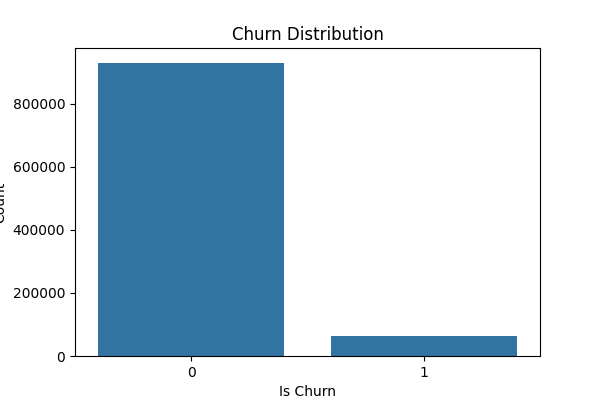

In [41]:
# histogram 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

churn_pdf = df.groupBy("is_churn").count().toPandas()

plt.figure(figsize=(6,4))
sns.barplot(data=churn_pdf, x="is_churn", y="count")
plt.title("Churn Distribution")
plt.xlabel("Is Churn")
plt.ylabel("Count")
plt.show()

%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

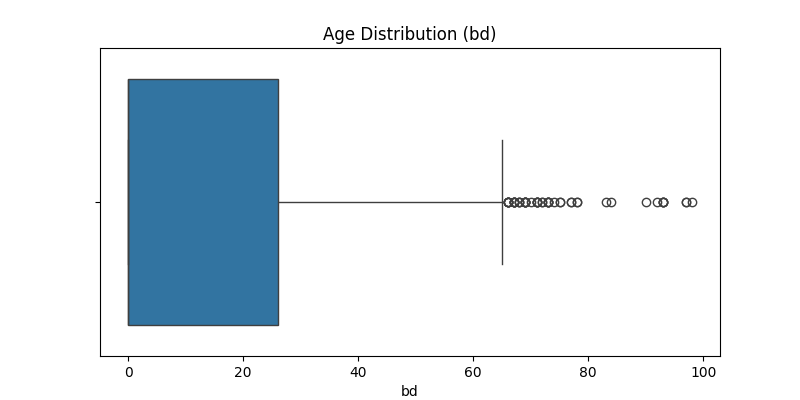

In [42]:
# age boxplot
sample_pdf = df.select("bd").sample(
    withReplacement=False,
    fraction=0.05,
    seed=42
).toPandas()

plt.figure(figsize=(8,4))
sns.boxplot(x=sample_pdf["bd"])
plt.title("Age Distribution (bd)")
plt.show()

%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

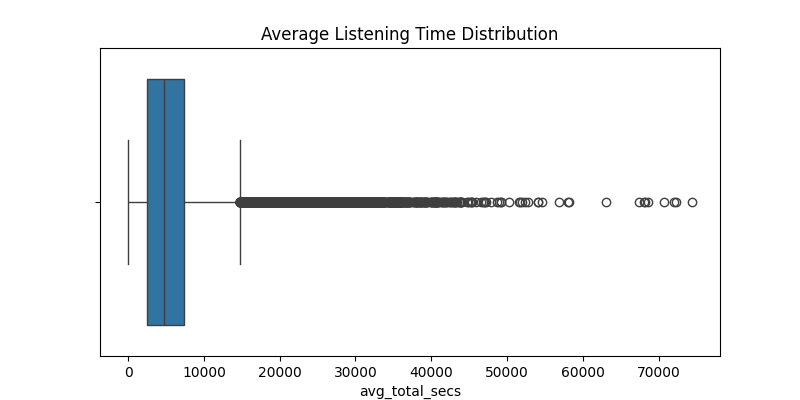

In [43]:
# listening time bloxplot
sample_pdf = df.select("avg_total_secs").sample(
    withReplacement=False,
    fraction=0.05,
    seed=42
).toPandas()

plt.figure(figsize=(8,4))
sns.boxplot(x=sample_pdf["avg_total_secs"])
plt.title("Average Listening Time Distribution")
plt.show()

%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

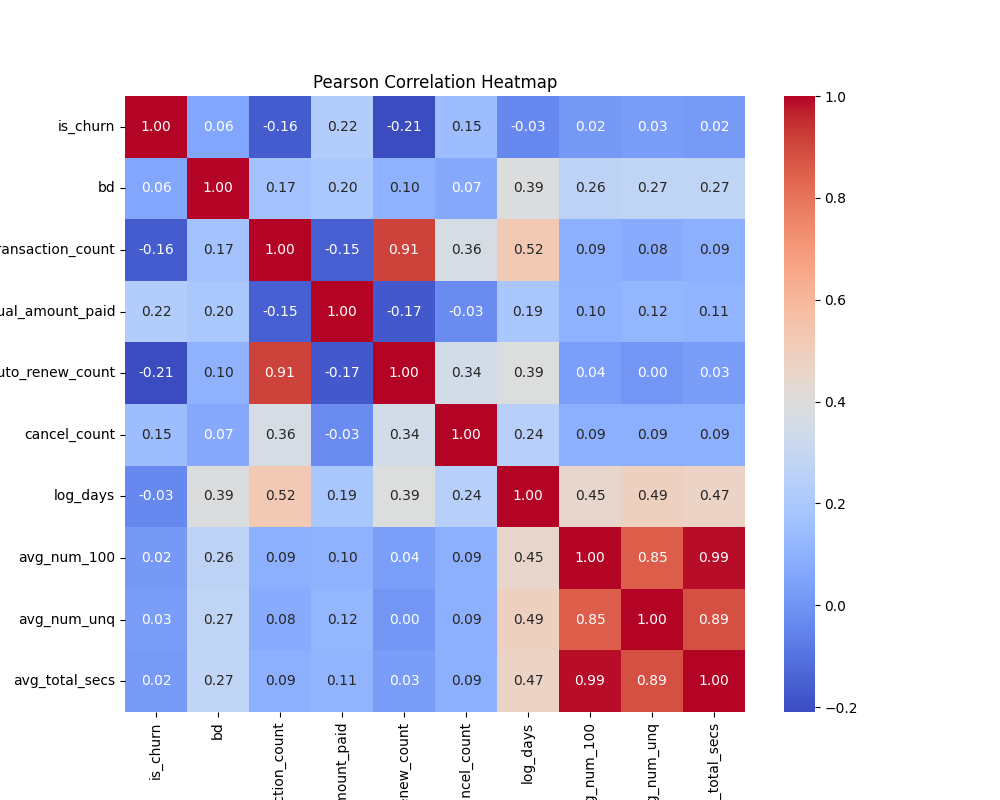

In [44]:
# Pearson correlation heatmap

corr_cols = [
    "is_churn",
    "bd",
    "transaction_count",
    "avg_actual_amount_paid",
    "auto_renew_count",
    "cancel_count",
    "log_days",
    "avg_num_100",
    "avg_num_unq",
    "avg_total_secs"
]

corr_pdf = df.select(corr_cols).sample(
    withReplacement=False,
    fraction=0.05,
    seed=42
).toPandas()

corr_matrix = corr_pdf.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Pearson Correlation Heatmap")
plt.show()

%matplot plt

In [45]:
# Correlation summary
'''
Positive Correlation:
As the feature value increases, the churn rate tends to increase.

Negative Correlation:
As the feature value increases, the churn rate tends to decrease.

Larger Absolute Correlation:
A larger absolute correlation value indicates a stronger relationship with churn.
'''

corr_matrix["is_churn"].sort_values(ascending=False)



# Correlation Analysis

# avg_actual_amount_paid, correlation = 0.222
  # - Higher average payment amounts are associated with higher churn rates.

# cancel_count, correlation = 0.148
  # - More subscription cancellations are associated with higher churn rates.

# bd (age), correlation = 0.056
  # - Age shows only a weak relationship with churn.

# avg_num_unq, correlation = 0.027
  # - The number of unique songs played has little impact on churn.

# avg_total_secs, correlation = 0.018
  # - Listening duration has a very weak correlation with churn.

# avg_num_100, correlation = 0.016
  # - The number of completed songs played has minimal correlation with churn.

# log_days, correlation = -0.035
  # - Users active on more days tend to be slightly less likely to churn.

# transaction_count, correlation = -0.164
  # - Users with more transactions are less likely to churn.
  # - Active paying customers tend to remain subscribed.

# auto_renew_count, correlation = -0.210
  # - More auto-renewals are associated with lower churn rates.
  # - Users with frequent subscription renewals are less likely to leave the platform.

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

is_churn                  1.000000
avg_actual_amount_paid    0.222434
cancel_count              0.147720
bd                        0.055916
avg_num_unq               0.027279
avg_total_secs            0.018365
avg_num_100               0.015656
log_days                 -0.034904
transaction_count        -0.163826
auto_renew_count         -0.209715
Name: is_churn, dtype: float64

In [46]:
from pyspark.ml.feature import StringIndexer

gender_indexer = StringIndexer(
    inputCol="gender",
    outputCol="gender_index",
    handleInvalid="keep"
)

df = gender_indexer.fit(df).transform(df)

df.select(
    "gender",
    "gender_index"
).show(10)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------+------------+
| gender|gender_index|
+-------+------------+
|Unknown|         0.0|
|   male|         1.0|
|Unknown|         0.0|
|   male|         1.0|
|Unknown|         0.0|
|Unknown|         0.0|
|Unknown|         0.0|
|   male|         1.0|
| female|         2.0|
| female|         2.0|
+-------+------------+
only showing top 10 rows

In [47]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "city",
    "bd",
    "registered_via",
    "transaction_count",
    "avg_payment_plan_days",
    "avg_plan_list_price",
    "avg_actual_amount_paid",
    "auto_renew_count",
    "cancel_count",
    "log_days",
    "avg_num_25",
    "avg_num_50",
    "avg_num_75",
    "avg_num_985",
    "avg_num_100",
    "avg_num_unq",
    "avg_total_secs",
    "sum_total_secs",
    "gender_index"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_ml = assembler.transform(df)

df_ml.select(
    "is_churn",
    "features"
).show(5, truncate=False)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+--------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|is_churn|features                                                                                                                                                                                                                                      |
+--------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|0       |[1.0,0.0,7.0,28.0,28.928571428571427,133.32142857142858,132.60714285714286,28.0,2.0,363.0,2.0661157024793386,0.5895316804407713,0.3856749311294766,0.38292011019283745,19.289256198347108,20.258953168044076,4867.345922865014,1766846.57,0.0]|


In [48]:
# standardization for logistic regression
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=False
)

scaler_model = scaler.fit(df_ml)

df_ml_scaled = scaler_model.transform(df_ml)

df_ml_scaled.select(
    "is_churn",
    "scaled_features"
).show(5, truncate=False)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+--------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|is_churn|scaled_features                                                                                                                                                                                                                                                                                                                                      |
+--------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [49]:
# Train test split
train_df, test_df = df_ml_scaled.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Training rows: 794473
Testing rows: 198458

In [50]:
# Logistic Regression
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="is_churn",
    maxIter=10
)

lr_model = lr.fit(train_df)

lr_predictions = lr_model.transform(test_df)

lr_predictions.select(
    "is_churn",
    "prediction",
    "probability"
).show(10, truncate=False)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+--------+----------+-----------------------------------------+
|is_churn|prediction|probability                              |
+--------+----------+-----------------------------------------+
|0       |0.0       |[0.9950283365332483,0.004971663466751708]|
|0       |0.0       |[0.7507148762213655,0.24928512377863454] |
|0       |0.0       |[0.9914496210216573,0.008550378978342654]|
|0       |0.0       |[0.9154574124445526,0.08454258755544741] |
|0       |0.0       |[0.9925728102261762,0.007427189773823839]|
|0       |0.0       |[0.8329483012706,0.16705169872939996]    |
|0       |0.0       |[0.9808382431306254,0.019161756869374602]|
|0       |0.0       |[0.9705837875253351,0.02941621247466486] |
|1       |0.0       |[0.8434041807724381,0.15659581922756194] |
|0       |0.0       |[0.8995860405796113,0.10041395942038867] |
+--------+----------+-----------------------------------------+
only showing top 10 rows

In [51]:
# Logistic model evaluation
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="is_churn",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="accuracy"
)

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="weightedRecall"
)

auc = auc_evaluator.evaluate(lr_predictions)
accuracy = accuracy_evaluator.evaluate(lr_predictions)
precision = precision_evaluator.evaluate(lr_predictions)
recall = recall_evaluator.evaluate(lr_predictions)

print("AUC =", auc)
print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)

lr_predictions.groupBy(
    "is_churn",
    "prediction"
).count().show()


VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

AUC = 0.8703138793793335
Accuracy = 0.934336800680385
Precision = 0.9071107526308689
Recall = 0.934336800680385
+--------+----------+------+
|is_churn|prediction| count|
+--------+----------+------+
|       1|       1.0|   960|
|       0|       0.0|184521|
|       0|       1.0|  1355|
|       1|       0.0| 11622|
+--------+----------+------+

In [52]:
# Random Forest
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="is_churn",
    featuresCol="scaled_features",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [53]:
# Random Forest evaluation
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

auc = BinaryClassificationEvaluator(
    labelCol="is_churn",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(rf_predictions)

accuracy = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(rf_predictions)

precision = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(rf_predictions)

recall = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(rf_predictions)

print("Random Forest Results")
print("AUC =", auc)
print("Accuracy =", accuracy)
print("Precision =", precision)
print("Recall =", recall)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Random Forest Results
AUC = 0.947481771979567
Accuracy = 0.9488100809718637
Precision = 0.9404876616172759
Recall = 0.9488100809718636

In [54]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    labelCol="is_churn",
    featuresCol="scaled_features",
    maxIter=50,
    maxDepth=5,
    seed=42
)

gbt_model = gbt.fit(train_df)

gbt_predictions = gbt_model.transform(test_df)



VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [55]:
gbt_auc = BinaryClassificationEvaluator(
    labelCol="is_churn",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(gbt_predictions)

gbt_accuracy = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(gbt_predictions)

gbt_precision = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(gbt_predictions)

gbt_recall = MulticlassClassificationEvaluator(
    labelCol="is_churn",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(gbt_predictions)

print("Gradient-Boosted Trees Results")
print("AUC =", gbt_auc)
print("Accuracy =", gbt_accuracy)
print("Precision =", gbt_precision)
print("Recall =", gbt_recall)
# confusion matrix
gbt_predictions.groupBy("is_churn", "prediction").count().show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Gradient-Boosted Trees Results
AUC = 0.9497847928826586
Accuracy = 0.9484930376275093
Precision = 0.9399489321113265
Recall = 0.9484930376275093
+--------+----------+------+
|is_churn|prediction| count|
+--------+----------+------+
|       1|       1.0|  4111|
|       0|       0.0|184120|
|       0|       1.0|  1756|
|       1|       0.0|  8471|
+--------+----------+------+

In [ ]:
# optimized gradient boosting
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

gbt = GBTClassifier(
    labelCol="is_churn",
    featuresCol="scaled_features",
    seed=42
)

paramGrid = ParamGridBuilder() \
    .addGrid(gbt.maxIter, [20, 50]) \
    .addGrid(gbt.maxDepth, [3, 5]) \
    .build()

cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=2
)

cv_model = cv.fit(train_df)

# Make predictions using optimized GBT model
cv_predictions = cv_model.transform(test_df)

# Evaluate optimized GBT model
cv_auc = auc_evaluator.evaluate(cv_predictions)
cv_accuracy = accuracy_evaluator.evaluate(cv_predictions)
cv_precision = precision_evaluator.evaluate(cv_predictions)
cv_recall = recall_evaluator.evaluate(cv_predictions)

print("Optimized Gradient-Boosted Trees Results")
print("AUC =", cv_auc)
print("Accuracy =", cv_accuracy)
print("Precision =", cv_precision)
print("Recall =", cv_recall)
# confusion matrix
cv_predictions.groupBy(
    "is_churn",
    "prediction"
).count().show()

best_gbt_model = cv_model.bestModel
print("Best maxIter:", best_gbt_model.getMaxIter())
print("Best maxDepth:", best_gbt_model.getMaxDepth())

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Optimized Gradient-Boosted Trees Results
AUC = 0.9482765453143795
Accuracy = 0.9484980700615466
Precision = 0.9399565412239512
Recall = 0.9484980700615466
+--------+----------+------+
|is_churn|prediction| count|
+--------+----------+------+
|       1|       1.0|  4111|
|       0|       0.0|184120|
|       0|       1.0|  1756|
|       1|       0.0|  8471|
+--------+----------+------+

Best maxIter: 50
Best maxDepth: 5

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

[]